In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import time
import json
from numpy.random import choice
import matplotlib.pyplot as plt
from myfunctions import *

with open('tree_p7.json') as json_file:
    tree_p7 = json.load(json_file)
with open('tree_p8.json') as json_file:
    tree_p8 = json.load(json_file)
with open('tree_p24.json') as json_file:
    tree_p24 = json.load(json_file)
with open('tree_p34.json') as json_file:
    tree_p34 = json.load(json_file)
with open('tree_p46.json') as json_file:
    tree_p46 = json.load(json_file)
with open('tree_p52.json') as json_file:
    tree_p52 = json.load(json_file)
    
tree_p7 = get_corrected_dict(tree_p7)
tree_p8 = get_corrected_dict(tree_p8)
tree_p24 = get_corrected_dict(tree_p24)
tree_p34 = get_corrected_dict(tree_p34)
tree_p46 = get_corrected_dict(tree_p46)
tree_p52 = get_corrected_dict(tree_p52)

## Functions

In [2]:
def get_root(node, tree):
    while(True):
        if(len(tree[node]["parent"])==0):
            return node
        node = tree[node]["parent"][0]

def get_initial_population(pop_size, roots, subchildren):
    population = []
    for pop in range(pop_size):
        cluster = []
        for root in roots:
            subchild = subchildren[root]
            random_num = random.randint(0, len(subchild))
            if(random_num == len(subchild)):
                cluster.append(root)
            else:
                cluster.extend(subchild[random_num])
        population.append(cluster)
    return population

def get_fitness(population, dist):
    pop_size = len(population)
    fitness_vec = []
    for pop in range(pop_size):
        a = list(population[pop])
        length = len(a)
        total_distance = 0
        for i in range(length):
            for j in range(i+1, length):
                total_distance += dist[a[i]][a[j]]
        total_pairs = length*((length-1)/2.0)
        fitness_vec.append(total_pairs/total_distance) ## inverse of avg distance
    return fitness_vec

######################################## NEW ADDITION ########################################################

def get_fitness_nearestNeighbour(population, dist):
    pop_size = len(population)
    fitness_vec = []
    for pop in range(pop_size):
        a = list(population[pop])
        length = len(a)
        total_distance = 0
        for i in range(length):
#             print("\nNEW ELEMENT")
            cur_closest_distance = 100000000
            for j in range(length):
                if(i!=j):
                    cur_distance = dist[a[i]][a[j]]
#                     print(cur_distance)
                    if(cur_distance < cur_closest_distance):
                        cur_closest_distance = cur_distance
#                         print("Closest distance updated to", cur_closest_distance)
#             print("FINAL CLOSEST DISTANCE FOR THE NEW ELEMENT", cur_closest_distance)
            total_distance += cur_closest_distance
#             print("NEW TOTAL DISTANCE", total_distance)
#         print("\nFINAL TOTAL DISTANCE", total_distance)
#         print("LENGTH", length)
#         print(length/total_distance)
        fitness_vec.append(length/total_distance) ## inverse of avg nearest neighbour distance
    return fitness_vec

def get_fitness_KnearestNeighbour(population, dist, knn):
    pop_size = len(population)
    fitness_vec = []
    for pop in range(pop_size):
        a = list(population[pop])
        length = len(a)
        if(knn > (length-1) or knn<1):
            print("Choose an appropriate K-NN value -> [1, number of roots - 1]")
            return -1
        total_distance = 0
        for i in range(length):
            cur_distance = []
            for j in range(length):
                if(i!=j):
                    cur_distance.append(dist[a[i]][a[j]])
#             print("\nNEW ELEMENT")
#             print(cur_distance)
#             print("SORTING....")
            cur_distance = np.sort(np.array(cur_distance))
#             print(cur_distance)
            cur_closest_distance = np.sum(cur_distance[:knn])/knn
#             print("AVERAGE CLOSEST DISTANCE", cur_closest_distance)
            total_distance += cur_closest_distance
#             print("TOTAL DISTANCE TILL NOW", total_distance)
#         print("LENGTH", length)
#         print(length/total_distance)
        fitness_vec.append(length/total_distance) ## inverse of avg nearest neighbour distance
    return fitness_vec

######################################## NEW ADDITION ########################################################

def mutate_cluster(x, cluster, tree, subchildren):
    for mutations in range(x): 
        node = cluster[random.randint(0, len(cluster)-1)]
        root = get_root(node, tree)
        cluster2 = []
        for clus in cluster:
            if(get_root(clus,tree) == root):
                continue
            cluster2.append(clus)
        cluster = list(cluster2)
        subchild = subchildren[root]
        random_num = random.randint(0, len(subchild))
        if(random_num == len(subchild)):
            cluster.append(root)
        else:
            cluster.extend(subchild[random_num])   
    return cluster

def get_parents(power, fitness_vec):
    sampleList = range(len(fitness_vec))
    fitness_vec_updated = [number**power for number in fitness_vec]
    fitness_vec_scaled = fitness_vec_updated/np.sum(fitness_vec_updated)
    parent_indices = choice(sampleList, p=fitness_vec_scaled, size=2, replace=False)
    return parent_indices

def crossover(parent1, parent2, roots, tree):
    cross_over_point = random.randint(1, len(roots)-1)
    child1 = []
    child2 = []
    for node in parent1:
        s = get_root(node, tree)
        if(s<cross_over_point):
            child1.append(node)
        else:
            child2.append(node)
    for node in parent2:
        s = get_root(node, tree)
        if(s<cross_over_point):
            child2.append(node)
        else:
            child1.append(node)
            
    return [child1, child2]

In [3]:
def genetic_algo(pop_size, num_generation, stop_criteria, mutations, power, knn, tree, roots, subchildren, dist, pflag):
    
    population = get_initial_population(pop_size, roots, subchildren)
    no_change = 0
    best_score = 100000000
    best_cluster = []
    cur_score_arr = []
    
    for gen in range(num_generation):
        if(pflag): print("BEST:",best_score, best_cluster)
        if(no_change >= stop_criteria):
            break
        ############################### MODIFIED ########################################
#         fitness = get_fitness(population, dist)
        if(knn == 1):
            fitness = get_fitness_nearestNeighbour(population, dist)
        else:
            fitness = get_fitness_KnearestNeighbour(population, dist, knn)
        ############################### MODIFIED ########################################
        cur_score = 1/(np.max(fitness))
        cur_score_arr.append(cur_score)
        if(cur_score < best_score):
            best_cluster = population[np.argmax(fitness)]
            best_score = cur_score
            no_change = -1
        new_population = []
        for i in range(int(pop_size/2)):
            parents = get_parents(power, fitness)
            parent1 = population[parents[0]]
            parent2 = population[parents[1]]
            [child1, child2] = crossover(parent1, parent2, roots, tree)
            new_population.append(child1)
            new_population.append(child2)
        final_population = []
        for cluster in new_population:
            num_muts = random.randint(0, mutations)
            final_population.append(mutate_cluster(num_muts, cluster, tree, subchildren))
        population = list(final_population)
        no_change += 1
        
    return (best_score, best_cluster, cur_score_arr)

# RUNNING THE GENETIC ALGORITHM

## P7

46.25658631324768
37.19592071905677 [245, 159, 158, 191, 193, 63, 125, 123, 186, 54, 52, 238, 239, 68, 163, 65, 194, 167, 164, 148, 208, 145, 205, 84, 83, 212, 178, 45, 228, 229, 201, 171, 170, 34, 137, 200, 109, 188]


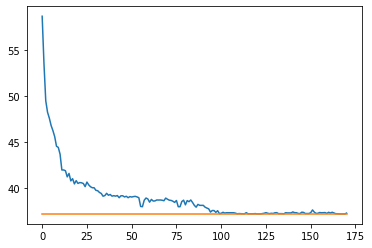

In [7]:
shapes_dist_euc = np.load("p7_ShapeDist_6144_Euc.npy")
tree = tree_p7

subchildren = get_complete_children_sets(tree)
roots = get_roots(tree)

pop_size = 500
num_generations = 200
stop_criteria = 50
mutation_rate = 5
power = 20
knn = 1
pflag = 0

t1 = time.time()
(a,b,c) = genetic_algo(pop_size, num_generations, stop_criteria, mutation_rate, power, knn, tree, roots, subchildren, shapes_dist_euc, pflag)
t2 = time.time()
print(t2-t1)

print(a,b)
plt.plot(range(len(c)), c)
plt.plot(range(len(c)), np.ones(len(c))*a)

## P8

58.65162014961243
70.19255203229163 [45, 116, 112, 111, 75, 232, 233, 180, 236, 43, 231, 201, 228, 107, 229, 47, 48, 51, 122, 152, 119, 243, 89, 55, 56, 128, 159, 158, 161, 162, 134, 135, 226, 199, 222, 195, 224, 132, 104]


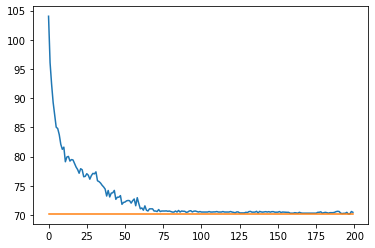

In [10]:
shapes_dist_euc = np.load("p8_ShapeDist_6144_Euc.npy")
tree = tree_p8

subchildren = get_complete_children_sets(tree)
roots = get_roots(tree)

pop_size = 500
num_generations = 200
stop_criteria = 50
mutation_rate = 5
power = 20
knn = 1
pflag = 0

t1 = time.time()
(a,b,c) = genetic_algo(pop_size, num_generations, stop_criteria, mutation_rate, power, knn, tree, roots, subchildren, shapes_dist_euc, pflag)
t2 = time.time()
print(t2-t1)

print(a,b)
plt.plot(range(len(c)), c)
plt.plot(range(len(c)), np.ones(len(c))*a)

## P24

52.60755276679993
44.72214990472098 [232, 79, 78, 77, 33, 76, 187, 114, 32, 116, 231, 184, 111, 25, 240, 164, 215, 41, 128, 43, 86, 195, 132, 204, 58, 243, 96, 203, 141, 142, 200, 91, 242, 174, 108, 228, 103, 62, 208, 106, 147, 239]


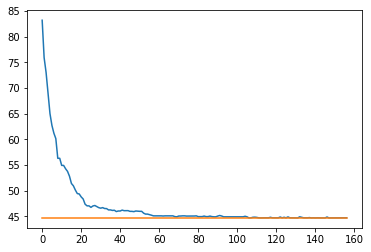

In [11]:
shapes_dist_euc = np.load("p24_ShapeDist_6144_Euc.npy")
tree = tree_p24

subchildren = get_complete_children_sets(tree)
roots = get_roots(tree)

pop_size = 500
num_generations = 200
stop_criteria = 50
mutation_rate = 5
power = 20
knn = 1
pflag = 0

t1 = time.time()
(a,b,c) = genetic_algo(pop_size, num_generations, stop_criteria, mutation_rate, power, knn, tree, roots, subchildren, shapes_dist_euc, pflag)
t2 = time.time()
print(t2-t1)

print(a,b)
plt.plot(range(len(c)), c)
plt.plot(range(len(c)), np.ones(len(c))*a)

## P34

54.93465256690979
49.477243071982464 [194, 92, 195, 227, 133, 132, 228, 256, 22, 68, 172, 138, 66, 99, 28, 237, 34, 141, 264, 108, 47, 83, 116, 117, 42, 242, 179, 115, 5, 245, 148, 240, 247, 88, 156, 188, 11, 251, 193, 221, 135]


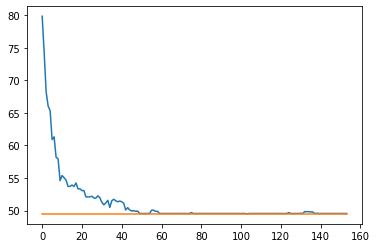

In [12]:
shapes_dist_euc = np.load("p34_ShapeDist_6144_Euc.npy")
tree = tree_p34

subchildren = get_complete_children_sets(tree)
roots = get_roots(tree)

pop_size = 500
num_generations = 200
stop_criteria = 50
mutation_rate = 5
power = 20
knn = 1
pflag = 0

t1 = time.time()
(a,b,c) = genetic_algo(pop_size, num_generations, stop_criteria, mutation_rate, power, knn, tree, roots, subchildren, shapes_dist_euc, pflag)
t2 = time.time()
print(t2-t1)

print(a,b)
plt.plot(range(len(c)), c)
plt.plot(range(len(c)), np.ones(len(c))*a)

## P46

21.11500644683838
52.9006847388076 [22, 78, 130, 24, 71, 42, 43, 97, 48, 74, 73, 152, 92, 67, 168, 133, 29, 58, 112, 139, 116, 65, 185, 162, 160, 41, 55, 106]


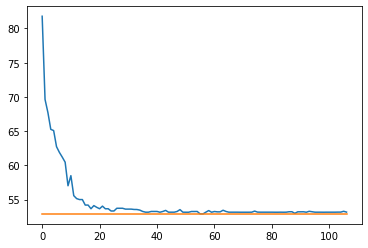

In [9]:
shapes_dist_euc = np.load("p46_ShapeDist_6144_Euc.npy")
tree = tree_p46

subchildren = get_complete_children_sets(tree)
roots = get_roots(tree)

pop_size = 500
num_generations = 200
stop_criteria = 50
mutation_rate = 5
power = 20
knn = 1
pflag = 0

t1 = time.time()
(a,b,c) = genetic_algo(pop_size, num_generations, stop_criteria, mutation_rate, power, knn, tree, roots, subchildren, shapes_dist_euc, pflag)
t2 = time.time()
print(t2-t1)

print(a,b)
plt.plot(range(len(c)), c)
plt.plot(range(len(c)), np.ones(len(c))*a)

## P52

72.02362751960754
41.2652233024699 [147, 33, 222, 74, 190, 191, 155, 28, 145, 181, 146, 152, 188, 143, 102, 277, 142, 210, 57, 136, 17, 95, 118, 261, 228, 120, 263, 161, 123, 243, 272, 169, 49, 166, 91, 204, 86, 246, 139, 177, 137, 125]


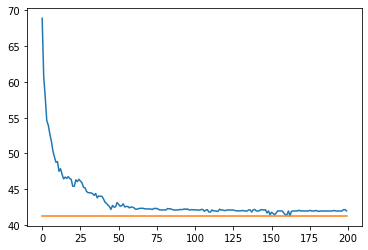

In [13]:
shapes_dist_euc = np.load("p52_ShapeDist_6144_Euc.npy")
tree = tree_p52

subchildren = get_complete_children_sets(tree)
roots = get_roots(tree)

pop_size = 500
num_generations = 200
stop_criteria = 50
mutation_rate = 5
power = 20
knn = 1
pflag = 0

t1 = time.time()
(a,b,c) = genetic_algo(pop_size, num_generations, stop_criteria, mutation_rate, power, knn, tree, roots, subchildren, shapes_dist_euc, pflag)
t2 = time.time()
print(t2-t1)

print(a,b)
plt.plot(range(len(c)), c)
plt.plot(range(len(c)), np.ones(len(c))*a)

## Verifying if the returned clusters are Valid & Correct

In [7]:
check_validity_correctness([245, 159, 158, 191, 193, 63, 125, 123, 186, 54, 52, 238, 239, 68, 163, 65, 194, 167, 164, 148, 208, 145, 205, 84, 83, 212, 178, 45, 228, 229, 201, 171, 170, 34, 137, 200, 109, 188], tree_p7)
check_validity_correctness([45, 116, 112, 111, 75, 232, 233, 180, 236, 43, 231, 201, 228, 107, 229, 47, 48, 51, 122, 152, 119, 243, 89, 55, 56, 128, 159, 158, 161, 162, 134, 135, 226, 199, 222, 195, 224, 132, 104], tree_p8)
check_validity_correctness([232, 79, 78, 77, 33, 76, 187, 114, 32, 116, 231, 184, 111, 25, 240, 164, 215, 41, 128, 43, 86, 195, 132, 204, 58, 243, 96, 203, 141, 142, 200, 91, 242, 174, 108, 228, 103, 62, 208, 106, 147, 239], tree_p24)
check_validity_correctness([194, 92, 195, 227, 133, 132, 228, 256, 22, 68, 172, 138, 66, 99, 28, 237, 34, 141, 264, 108, 47, 83, 116, 117, 42, 242, 179, 115, 5, 245, 148, 240, 247, 88, 156, 188, 11, 251, 193, 221, 135], tree_p34)
check_validity_correctness([22, 78, 130, 24, 71, 42, 43, 97, 48, 74, 73, 152, 92, 67, 168, 133, 29, 58, 112, 139, 116, 65, 185, 162, 160, 41, 55, 106], tree_p46)
check_validity_correctness([147, 33, 222, 74, 190, 191, 155, 28, 145, 181, 146, 152, 188, 143, 102, 277, 142, 210, 57, 136, 17, 95, 118, 261, 228, 120, 263, 161, 123, 243, 272, 169, 49, 166, 91, 204, 86, 246, 139, 177, 137, 125], tree_p52)

OK!!
OK!!
OK!!
OK!!
OK!!
OK!!
